In [2]:
from modules import *
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Eurostat Turnover

In [3]:

to = get_eurostats_turnover()
to


/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,country,year,turnover
12,Spain,2011,469674.3
64,Spain,2012,457032
116,Spain,2013,447414.9
168,Spain,2014,455944.5
220,Spain,2015,467052.8
272,Spain,2016,466087.9
324,Spain,2017,505350.9
376,Spain,2018,551091.3
428,Spain,2019,560854.9
480,Spain,2020,497125.6


### Price Indexes Eurostat

In [ ]:
ps = price_indexes('Spain')

ps

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,sector2d,year,priceind
0,05,2016,NaN
1,06,2016,NaN
2,07,2016,NaN
3,08,2016,0.956
4,09,2016,NaN
...,...,...,...
305,31,2025,1.139
306,32,2025,1.127
307,33,2025,1.108
308,35,2025,1.327


In [ ]:
capi = capital_prices('Spain')

capi


/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,country,year,capitalprice
14,Spain,2015,1.000
63,Spain,2016,1.006
112,Spain,2017,1.015
161,Spain,2018,1.024
210,Spain,2019,1.034
259,Spain,2020,1.043
308,Spain,2021,1.064
357,Spain,2022,1.121
406,Spain,2023,1.158
455,Spain,2024,NaN


### Real Interest Rate
To calculate real Interest rate we use [nominal interest rate](https://ec.europa.eu/eurostat/databrowser/view/irt_lt_mcby_a__custom_21686442/default/table) and [inflation rates](https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_ainr__custom_21686600/default/table) from Eurostat.

$$ r_t^{\text{real}} = \frac{1 + r_t^{\text{nominal}}}{1 + \pi_t} - 1 $$

$$ r_t^{\text{real}} \approx r_t^{\text{nominal}} - \pi_t $$

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


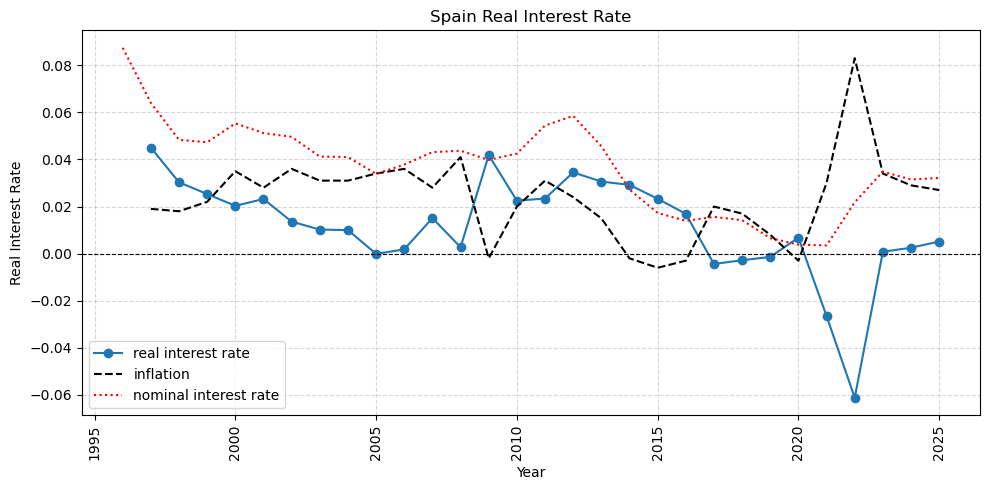

In [ ]:
rirate = get_real_interest_rate('Spain')



plt.figure(figsize=(10, 5))

plt.plot(rirate['year'], rirate['realinterestrate'], marker='o', linestyle='-', label = 'real interest rate')
plt.plot(rirate['year'], rirate['inflation'], linestyle='--', color='black', label='inflation')
plt.plot(rirate['year'], rirate['nominalinterestrate'], linestyle=':', color='red', label='nominal interest rate')


plt.xlabel("Year")
plt.ylabel("Real Interest Rate")
plt.title("Spain Real Interest Rate")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/realinterestrate.png', dpi=300)

plt.show()

### read orbis data

In [7]:
#get list of relevant files
#folder = "Data/Export w Debt 050626"
folder = "Data/Export 270426"
#df_long = prepare_orbis_excel(folder)
df_long = read_parquet('ES')

NUM_COLS = [
'assets',
'revenue',
'materials'
] + (['wagebill'] if 'wagebill' in df_long.columns else ['wage', 'debt'])

#drop companies who have missing financial information in a given year
#df_long = df_long.dropna(subset=NUM_COLS, how='any')

#merge priceindexes 
df_long['sector2d'] = df_long['sector'].astype(str).str[:2]
df_long['year'] = df_long['year'].astype(str)
df_long = df_long.merge(ps, on=['sector2d', 'year'], how='left')
df_long = df_long.merge(capi, on='year', how='left')
df_long['year'] = df_long['year'].astype(int)
df_long = df_long.drop('sector2d', axis=1)
df_long['priceind'] = np.where(df_long['year'] == 2015, 1, df_long['priceind'])


#drop empty price index
df_long = df_long[df_long['priceind'].notna()]
df_long = df_long[df_long['capitalprice'].notna()]

#calculate base variables
#calculate firm nominal value added
df_long['nvad'] = df_long['revenue'] - df_long['materials']

#deflate assets and wagebill to get k and l with pricindex
df_long['k'] = df_long['assets'] / df_long['capitalprice']   
df_long['y'] = df_long['nvad'] / df_long['priceind']

if 'wagebill' in df_long.columns:
    df_long['l'] = df_long['wagebill'] / df_long['priceind']
    df_long['w'] = (df_long['wagebill'] / df_long['nEmployees']) / df_long['priceind']
    COLS = ['k', 'l', 'y', 'w', 'nvad']
else:
    df_long['w'] = df_long['wage'] / df_long['priceind']
    df_long['b'] = df_long['debt'] / df_long['priceind']
    COLS = ['k', 'y', 'w','b', 'nvad']

#drop non positive values and prices
df_long = df_long[df_long['nvad'] > 0]
df_long = df_long[df_long['k'] > 0]
df_long = df_long[df_long['w'] > 0]



#add real interest rate
df_long = df_long.merge(rirate[['year', 'realinterestrate']], on='year', how='left')


#save to workspace for reusing
df_long.to_pickle("data_long.pkl")

df_long[COLS].describe()

,k,l,y,w,nvad
count,5.687410e+05,5.687410e+05,5.687410e+05,568741.000000,5.687410e+05
mean,5.209358e+03,1.387806e+03,3.960427e+03,32.019693,3.927240e+03
std,1.185477e+05,2.062835e+04,8.950175e+04,26.550641,8.979444e+04
min,1.934236e-05,5.704762e-03,1.816284e-03,0.005705,1.740000e-03
25%,1.158526e+02,7.218732e+01,1.204192e+02,21.527536,1.196305e+02
50%,3.381243e+02,1.844306e+02,3.142965e+02,28.750354,3.125887e+02
75%,1.200377e+03,5.111522e+02,9.620419e+02,38.564485,9.574934e+02
max,2.335682e+07,3.629898e+06,1.607257e+07,5423.490730,1.897500e+07


### compare eurostat and orbis data

In [9]:
#get infos of companies per year
counts = df_long.groupby('year').agg({'FirmName': 'count', 'revenue': 'sum'}).reset_index()
counts['year'] = counts['year'].astype(str)

#merge with eurostats turnover and compare
counts = counts.merge(to, how='left', on='year')
#set revenue to mios
counts['revenue'] = counts['revenue'] / 1000
#create coverage ratio
counts['ratio'] = (counts['revenue'] / counts['turnover'])

rename = {
    'year': 'Year',
    'revenue' : 'Revenue Orbis',
    'turnover': 'Turnover Eurostats',
    'ratio': 'Share Orbis'
}

counts = counts.rename(columns=rename)[rename.values()]

counts[['Year', 'Share Orbis']].to_latex(
    index=False,        # remove row numbers
    caption="Share of Eurostats Revenue in Orbis Firm-Level Data", # table caption
    label="tab:orbisshare",# for \ref{tab:mytable}
    float_format="%.2f" # round floats to 2 decimals
)

counts


,Year,Revenue Orbis,Turnover Eurostats,Share Orbis
0,2015,580001.155756,467052.8,1.241832
1,2016,622759.610053,466087.9,1.336142
2,2017,675920.937220,505350.9,1.337528
3,2018,704691.630434,551091.3,1.27872
4,2019,737565.952994,560854.9,1.315074
5,2020,625054.738403,497125.6,1.257338
6,2021,742715.723449,588190.29,1.262713
7,2022,914113.044374,707728.72,1.291615
8,2023,868875.095801,695856.81,1.248641
